# Task 6 Customer Churn Prediction

**NeuroFive ML Track Week 3: Machine Learning Fundamentals**

Churn prediction working out which customers are about to leave is one of the most commonly deployed ML problems in industry. Telecom, banking and SaaS companies all run models like this, because keeping an existing customer is far cheaper than acquiring a new one.

This notebook also introduces the **Decision Tree**, a model whose logic can be read directly as a series of if/else rules. That interpretability matters when the audience is a manager rather than an engineer.

**What this notebook does**

1. Loads and cleans the Telco Customer Churn dataset.
2. Runs EDA to find which features relate to churn.
3. Handles categorical variables and examines **class imbalance**.
4. Trains a **Decision Tree** and a **Logistic Regression**, then compares them.
5. Extracts the **top 3 churn drivers** using `.feature_importances_`.
6. Ends with a plain-English **business summary**.

**Dataset:** Telco Customer Churn (Kaggle / IBM sample data) 7,043 customers, 21 columns.

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")

## 1. Loading the Data

Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from Kaggle and upload it to Colab using the file panel on the left.

Once the file is committed to your GitHub repository you can skip the upload entirely by loading it from the raw URL instead the commented line below shows how.

In [5]:
url = "https://raw.githubusercontent.com/BadarRao/neurofive-ml-track/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Cleaning

### The `TotalCharges` problem

`df.info()` above reports `TotalCharges` as an **object** (text) column, even though it clearly holds money values. That is not a formatting quirk to ignore if left as text the column cannot be used by any model, and a naive `astype(float)` will crash.

The cause: a small number of rows contain a blank space instead of a number. The cell below converts the column to numeric, turning anything unparseable into `NaN`, then investigates which rows those are.

In [7]:
# errors='coerce' turns unparseable values into NaN instead of raising an error
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_total = df['TotalCharges'].isnull().sum()
print("Rows where TotalCharges could not be parsed:", missing_total)
print()

# What do those rows look like?
print("Tenure values for those rows:", df.loc[df['TotalCharges'].isnull(), 'tenure'].unique())
print()
print(df.loc[df['TotalCharges'].isnull(), ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Rows where TotalCharges could not be parsed: 11

Tenure values for those rows: [0]

      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No


### Why these rows are blank, and what to do about them

Every affected row has **`tenure = 0`** these are brand-new customers who have not yet been billed. The blank is not a data error; it genuinely means "nothing charged yet".

So the correct fix is to fill them with **0**, not the median. Using the median would invent a billing history for customers who have none, and would tell the model that a brand-new customer has already spent an average amount the opposite of the truth. This is a good example of why it is worth looking at *which* rows are missing before choosing a strategy.

In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Remaining missing values across the whole dataset:", df.isnull().sum().sum())

Remaining missing values across the whole dataset: 0


In [9]:
# customerID is a unique identifier - it carries no predictive information
# and would only add noise, so it is removed.
print("Unique customerIDs:", df['customerID'].nunique(), "out of", len(df), "rows")

df = df.drop(columns=['customerID'])

print("Columns remaining:", df.shape[1])

Unique customerIDs: 7043 out of 7043 rows
Columns remaining: 20


## 3. Class Imbalance

Before any modelling, check how many customers actually churned.

In [10]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)
print()
print("Churn percentages:")
print(churn_percent.round(2))

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


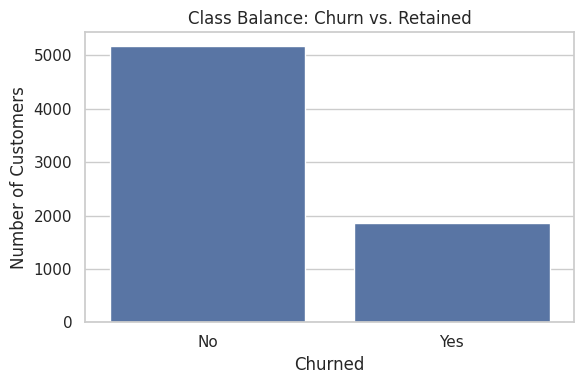

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(x='Churn', data=df)

plt.xlabel('Churned')
plt.ylabel('Number of Customers')
plt.title('Class Balance: Churn vs. Retained')
plt.tight_layout()
plt.show()

### Noting the imbalance

Roughly **three quarters of customers stayed and one quarter left**. This is a real imbalance — more pronounced than the Titanic dataset from Task 5, though far milder than something like fraud detection.

**Why it matters here:** a model that predicts "nobody churns" for every single customer would still score around 73% accuracy while being completely useless to the business. As established in Task 5, accuracy alone cannot be trusted on imbalanced data, so this notebook reports **precision, recall and F1** throughout.

**How it is addressed:** both models are trained twice — once with default settings, and once with `class_weight='balanced'`, which makes errors on the minority (churning) class count for more during training. Section 7 compares the two. This is a partial fix rather than a complete one; techniques such as SMOTE or adjusting the decision threshold would go further.

## 4. Exploratory Data Analysis

The goal here is to spot which features move together with churn, before any model is trained.

In [12]:
# Split columns into numerical and categorical for easier exploration
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_features = [c for c in df.columns if c not in numerical_features + ['Churn']]

print("Numerical features:", numerical_features)
print()
print("Categorical features:", categorical_features)

Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [13]:
df[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.162147
std,24.559481,30.090047,2266.794470,0.368612
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000
75%,55.000000,89.850000,3786.600000,0.000000
max,72.000000,118.750000,8684.800000,1.000000


### Churn rate by contract type

Contract type is the first thing to check it is usually the strongest single predictor in this dataset.

In [14]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

print("Churn rate by contract type (%):")
print(contract_churn.round(2))

Churn rate by contract type (%):
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


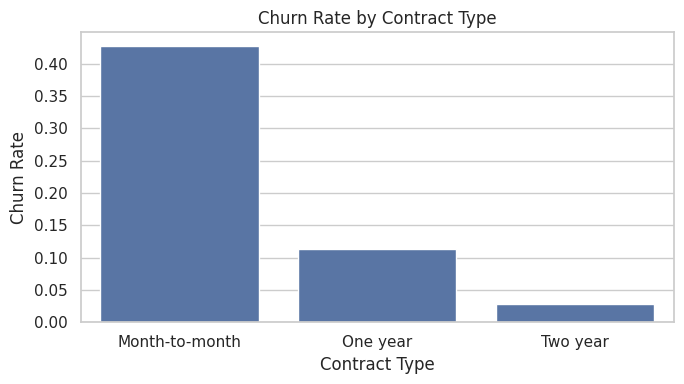

In [15]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x='Contract',
    y='Churn',
    data=df.assign(Churn=(df['Churn'] == 'Yes').astype(int)),
    errorbar=None
)

plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.title('Churn Rate by Contract Type')
plt.tight_layout()
plt.show()

### Churn rate across other key categorical features

Rather than plotting all sixteen categorical columns, the cell below focuses on the ones most likely to matter commercially.

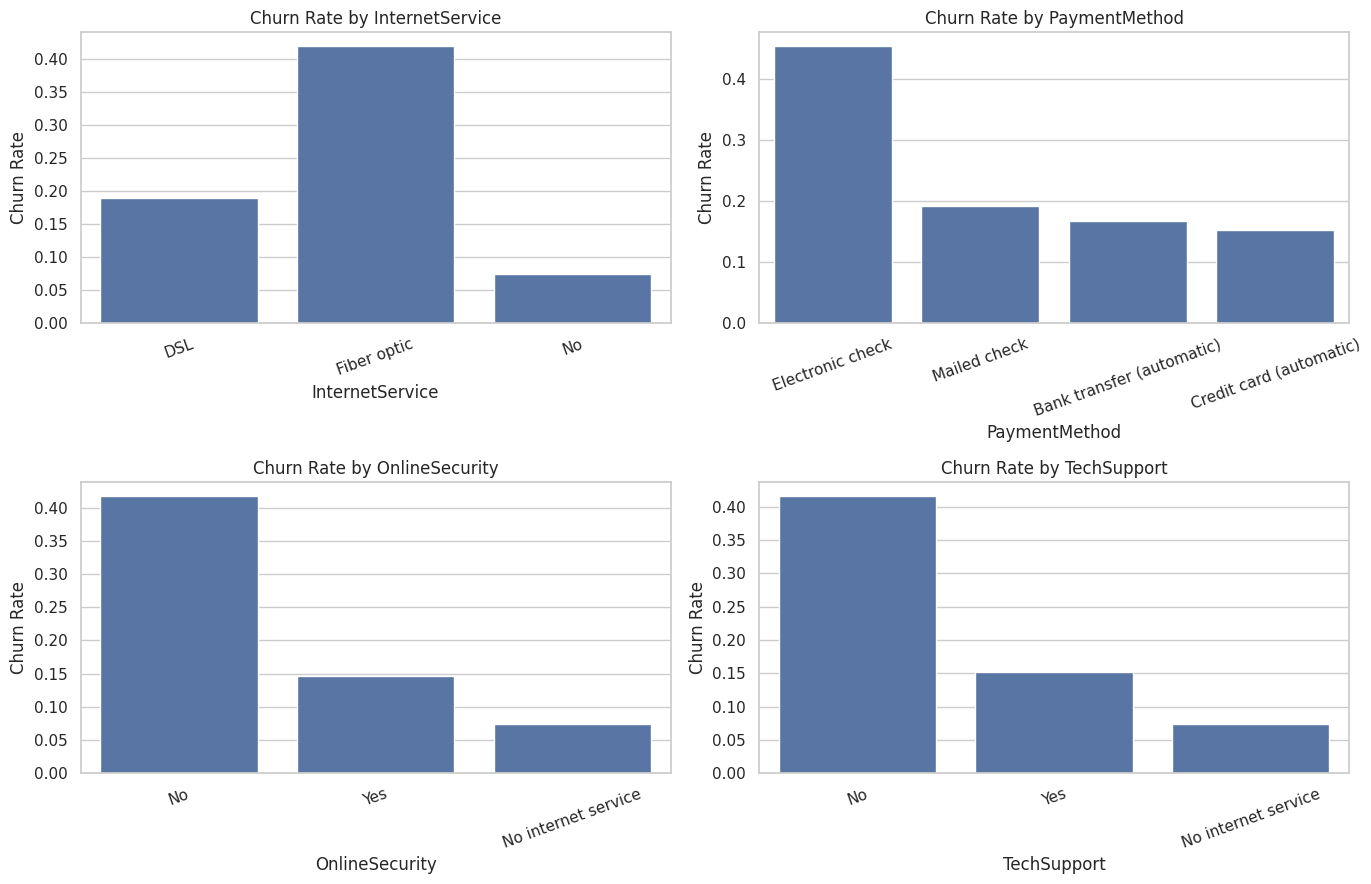

In [16]:
key_features = ['InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

churn_numeric = (df['Churn'] == 'Yes').astype(int)

for ax, feature in zip(axes.flatten(), key_features):
    sns.barplot(
        x=feature,
        y=churn_numeric,
        data=df,
        errorbar=None,
        ax=ax
    )
    ax.set_ylabel('Churn Rate')
    ax.set_title(f'Churn Rate by {feature}')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [17]:
# Print the same information as numbers
for feature in key_features:
    rate = df.groupby(feature)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    print(f"Churn rate by {feature} (%):")
    print(rate.round(2).to_string())
    print()

Churn rate by InternetService (%):
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40

Churn rate by PaymentMethod (%):
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11

Churn rate by OnlineSecurity (%):
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61

Churn rate by TechSupport (%):
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17



### Tenure and monthly charges

Two numerical features worth inspecting directly.

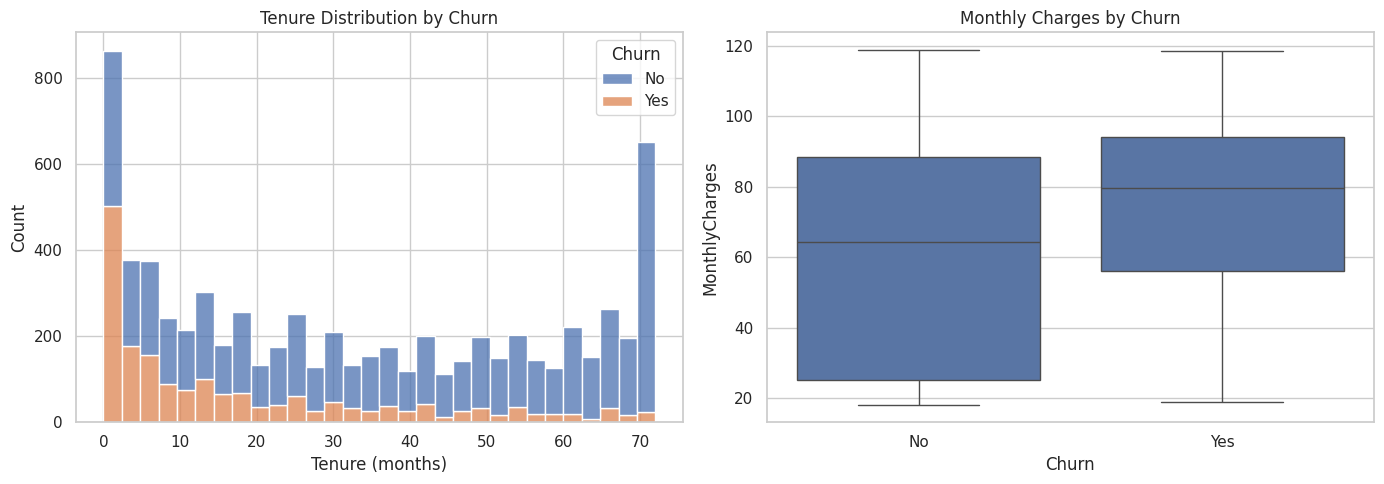

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (months)')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')

plt.tight_layout()
plt.show()

In [19]:
# Average values for customers who churned vs. those who stayed
print(df.groupby('Churn')[numerical_features].mean().round(2).to_string())

       tenure  MonthlyCharges  TotalCharges  SeniorCitizen
Churn                                                     
No      37.57           61.27       2549.91           0.13
Yes     17.98           74.44       1531.80           0.25


### Correlation between numerical features and churn

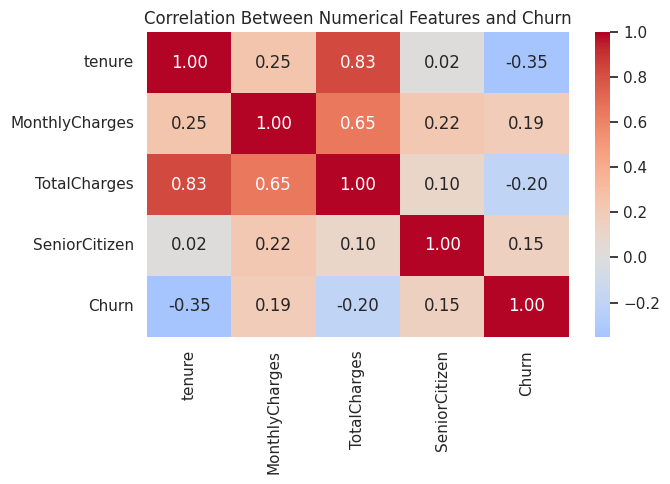

In [20]:
corr_df = df[numerical_features].copy()
corr_df['Churn'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(7, 5))

sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Between Numerical Features and Churn')
plt.tight_layout()
plt.show()

### EDA takeaways

Read the outputs above and note the pattern that emerges:

- **Contract type** shows a very large spread in churn rate across its three categories.
- **Tenure** is strongly negatively related to churn the longer someone has been a customer, the less likely they are to leave. The tenure histogram shows churn concentrated heavily in the first few months.
- **MonthlyCharges** is higher on average among customers who left.
- Customers **without** add-on services such as online security or tech support churn noticeably more than those who have them.

These are hypotheses drawn from the data, not proof of causation the models below will test whether they hold up.

## 5. Preparing Features for Modelling

The dataset is mostly categorical text (`Yes`/`No`, `DSL`/`Fiber optic`, and so on), which scikit-learn cannot consume directly.

**Encoding approach:** `OneHotEncoder` inside a `ColumnTransformer`, exactly as in Tasks 3 and 5. Each category becomes its own 0/1 column.

**Scaling:** numerical features are standardised for Logistic Regression, because it is sensitive to feature scale (`TotalCharges` runs into the thousands while `SeniorCitizen` is 0 or 1). Decision Trees are *not* affected by scale, since they split on thresholds rather than distances — but keeping one shared preprocessor is simpler and does the tree no harm.

In [21]:
# Target: convert Yes/No to 1/0
y = (df['Churn'] == 'Yes').astype(int)
X = df.drop(columns=['Churn'])

print("Feature matrix shape:", X.shape)
print("Target distribution:", y.value_counts().to_dict())

Feature matrix shape: (7043, 19)
Target distribution: {0: 5174, 1: 1869}


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', StandardScaler(), numerical_features)
    ]
)

# stratify=y keeps the same churn ratio in both train and test sets,
# which matters when the classes are imbalanced.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print()
print("Churn rate in training set:", round(y_train.mean() * 100, 2), "%")
print("Churn rate in test set:", round(y_test.mean() * 100, 2), "%")

Training samples: 5634
Testing samples: 1409

Churn rate in training set: 26.54 %
Churn rate in test set: 26.54 %


## 6. Training the Two Models

### Why limit the Decision Tree's depth?

Left unrestricted, a Decision Tree keeps splitting until every training example is perfectly classified. It memorises the training data including its noise and then performs poorly on anything new. This is **overfitting**.

The cell below demonstrates the problem before fixing it.

In [23]:
# An unrestricted tree, purely to demonstrate overfitting
overfit_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

overfit_tree.fit(X_train, y_train)

print("Unrestricted tree — training accuracy:",
      round(accuracy_score(y_train, overfit_tree.predict(X_train)), 4))
print("Unrestricted tree — test accuracy:    ",
      round(accuracy_score(y_test, overfit_tree.predict(X_test)), 4))
print()
print("A large gap between these two numbers is the signature of overfitting.")

Unrestricted tree — training accuracy: 0.998
Unrestricted tree — test accuracy:     0.7246

A large gap between these two numbers is the signature of overfitting.


The gap above is the reason the models below use `max_depth=5`. Limiting depth forces the tree to keep only the most useful splits, which improves generalisation *and* keeps the tree small enough for a human to read the whole selling point of this model type.

In [24]:
# Model 1: Logistic Regression
logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print("Logistic Regression trained.")

Logistic Regression trained.


In [25]:
# Model 2: Decision Tree
tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])

tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

print("Decision Tree trained.")

Decision Tree trained.


### Classification reports

Both models judged on precision, recall and F1 not accuracy alone.

In [26]:
print("=" * 55)
print("LOGISTIC REGRESSION")
print("=" * 55)
print(classification_report(y_test, logreg_pred, target_names=['Stayed', 'Churned']))

print("=" * 55)
print("DECISION TREE (max_depth=5)")
print("=" * 55)
print(classification_report(y_test, tree_pred, target_names=['Stayed', 'Churned']))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

DECISION TREE (max_depth=5)
              precision    recall  f1-score   support

      Stayed       0.85      0.88      0.87      1035
     Churned       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## 7. Comparing the Models

The table below reports metrics for the **churned** class, since identifying customers who are about to leave is the entire business purpose of the model.

Both models also appear in a `class_weight='balanced'` version, which is the partial fix for the imbalance noted in Section 3.

In [27]:
# Balanced-weight versions of both models
logreg_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
logreg_balanced.fit(X_train, y_train)
logreg_bal_pred = logreg_balanced.predict(X_test)

tree_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])
tree_balanced.fit(X_train, y_train)
tree_bal_pred = tree_balanced.predict(X_test)

print("Balanced versions trained.")

Balanced versions trained.


In [28]:
def get_metrics(y_true, y_pred):
    """Headline metrics for the positive (churned) class."""
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

comparison = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, logreg_pred),
    'Decision Tree': get_metrics(y_test, tree_pred),
    'Logistic Regression (balanced)': get_metrics(y_test, logreg_bal_pred),
    'Decision Tree (balanced)': get_metrics(y_test, tree_bal_pred)
})

print(comparison.round(4).to_string())

           Logistic Regression  Decision Tree  Logistic Regression (balanced)  Decision Tree (balanced)
Accuracy                0.8055         0.7984                          0.7381                    0.7544
Precision               0.6572         0.6347                          0.5043                    0.5260
Recall                  0.5588         0.5668                          0.7834                    0.7567
F1-Score                0.6040         0.5989                          0.6136                    0.6206


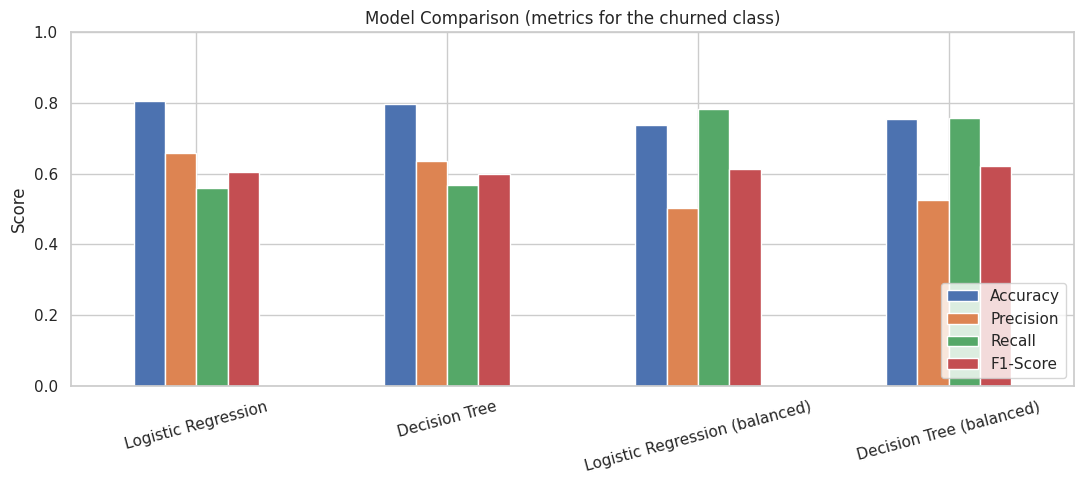

In [29]:
comparison.T.plot(kind='bar', figsize=(11, 5), rot=15)

plt.ylabel('Score')
plt.title('Model Comparison (metrics for the churned class)')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

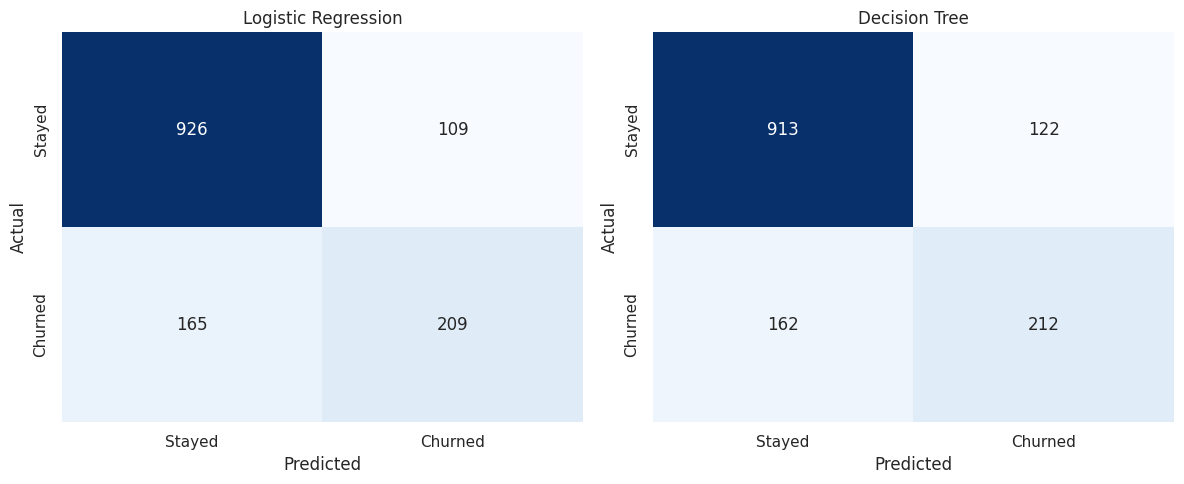

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Stayed', 'Churned']

for ax, preds, title in zip(
    axes,
    [logreg_pred, tree_pred],
    ['Logistic Regression', 'Decision Tree']
):
    sns.heatmap(
        confusion_matrix(y_test, preds),
        annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Interpreting the comparison

Compare the two default models first, then look at what `class_weight='balanced'` changed.

The balanced versions should show **higher recall and lower precision**: weighting the minority class makes each model more willing to flag a customer as a churn risk, so it catches more real churners but also raises more false alarms. Accuracy typically dips slightly.

Which behaviour is preferable is a **business decision, not a technical one**. If a retention offer costs a small discount, missing a churner (a false negative) is far more expensive than contacting a happy customer (a false positive) so recall should be favoured. That reasoning belongs to the manager, and the model should be tuned to match it.

## 8. Top 3 Features Driving Churn

`.feature_importances_` reports how much each feature contributed to reducing impurity across all splits in the tree. Higher means more influential.

Because `OneHotEncoder` expands each categorical column into several 0/1 columns, the feature names must be pulled out of the fitted preprocessor to label the importances correctly.

In [31]:
# Recover the expanded feature names created by the ColumnTransformer
feature_names = tree.named_steps['preprocessor'].get_feature_names_out()

importances = tree.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Total features after one-hot encoding:", len(feature_names))
print()
print("TOP 10 FEATURES BY IMPORTANCE")
print(importance_df.head(10).to_string(index=False))

Total features after one-hot encoding: 45

TOP 10 FEATURES BY IMPORTANCE
                                    Feature  Importance
       categorical__Contract_Month-to-month    0.513973
   categorical__InternetService_Fiber optic    0.163262
                          numerical__tenure    0.156717
                  numerical__MonthlyCharges    0.035922
                    numerical__TotalCharges    0.035791
categorical__PaymentMethod_Electronic check    0.027931
                categorical__TechSupport_No    0.021377
             categorical__Contract_One year    0.009218
               categorical__OnlineBackup_No    0.009198
             categorical__OnlineSecurity_No    0.008620


In [32]:
print("=" * 55)
print("TOP 3 FEATURES DRIVING CHURN")
print("=" * 55)

for rank, row in importance_df.head(3).iterrows():
    print(f"{rank + 1}. {row['Feature']}  —  importance {row['Importance']:.4f}")

TOP 3 FEATURES DRIVING CHURN
1. categorical__Contract_Month-to-month  —  importance 0.5140
2. categorical__InternetService_Fiber optic  —  importance 0.1633
3. numerical__tenure  —  importance 0.1567


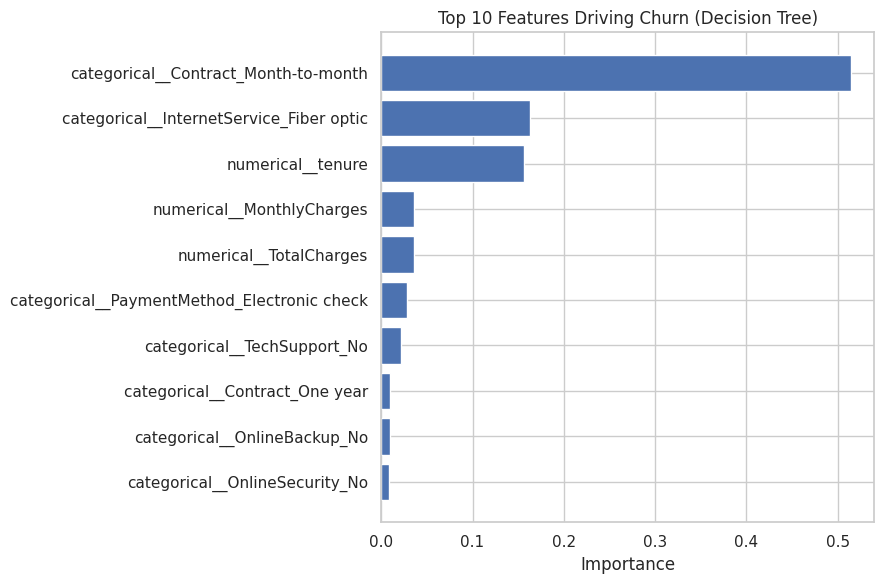

In [33]:
top_features = importance_df.head(10).iloc[::-1]

plt.figure(figsize=(9, 6))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel('Importance')
plt.title('Top 10 Features Driving Churn (Decision Tree)')
plt.tight_layout()
plt.show()

### A caution on feature importance

Feature importance shows what the **model relied on**, which is not the same as proven cause and effect. Two features that carry similar information can split the credit between them, making each look less important than it is.

It is still highly useful as a guide for where the business should investigate first.

## 9. Visualising the Decision Tree

The main advantage of a tree is that its logic can be read directly. The plot below shows the top three levels enough to see the rules the model learned without becoming unreadable.

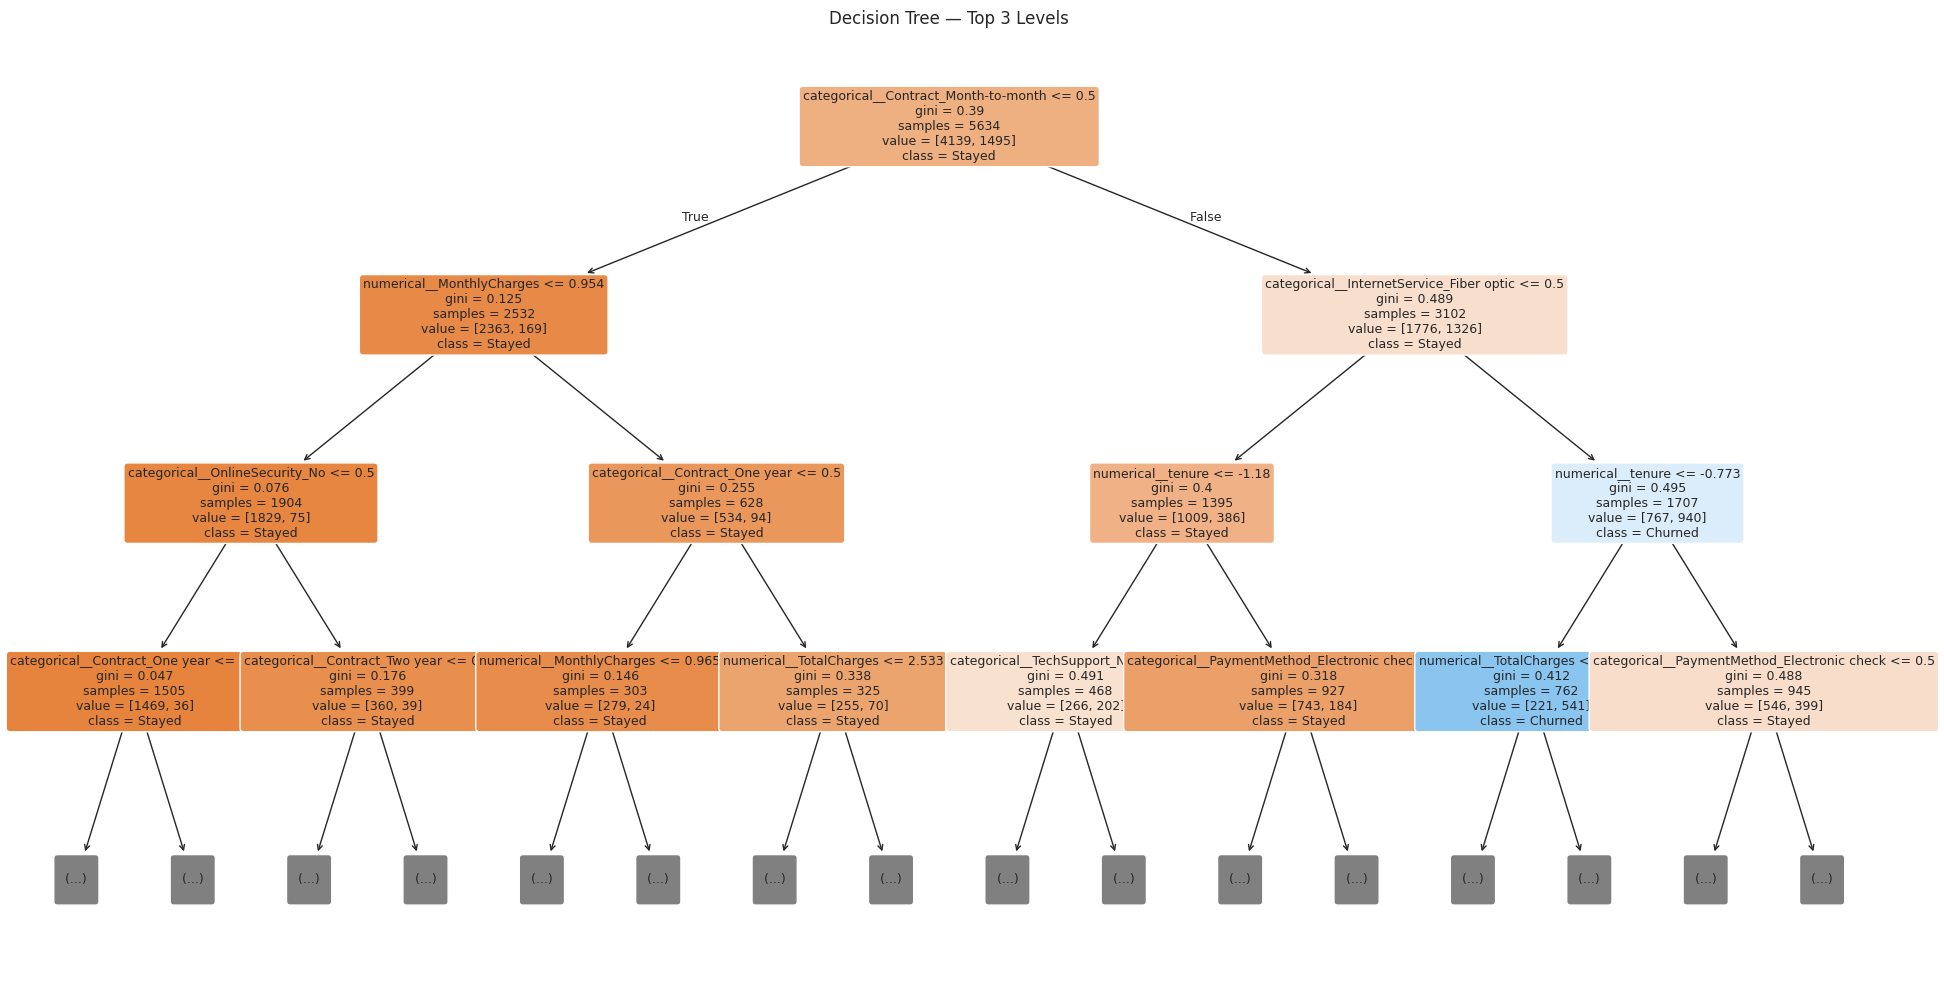

In [34]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree.named_steps['classifier'],
    feature_names=feature_names,
    class_names=['Stayed', 'Churned'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title('Decision Tree — Top 3 Levels')
plt.tight_layout()
plt.show()

Each box shows the rule being tested, how many training customers reached that point, and which way the model leans there. Following a path from top to bottom gives a rule in plain language, for example: *"month-to-month contract, short tenure, no tech support → likely to churn."*

That readability is exactly why Decision Trees are used in stakeholder-facing work, even when a more complex model scores slightly higher.

## 10. Business Summary

*Written for a non-technical manager.*

About **one in four of our customers is leaving**, and we can now predict which ones with reasonable reliability before they go. The single clearest warning sign is **contract type**: customers on month-to-month plans leave at a dramatically higher rate than those on one- or two-year contracts, who are largely locked in and stay. **How long someone has been a customer** is the next strongest signal most churn happens in the first several months, meaning the risk is concentrated among new customers rather than long-standing ones. We also see that customers paying **higher monthly charges**, particularly fiber-optic subscribers without support add-ons like online security or tech support, are more likely to leave.

The practical recommendation is to concentrate retention spending on **new, month-to-month, high-bill customers within their first year**, since that is where the risk sits. Offering an incentive to move onto an annual contract, or bundling in a support add-on, targets the two factors the data flags most strongly. One honest caveat: the model tells us *who* is at risk, not *why* any individual is unhappy it identifies where to look, and the conversation with the customer still has to happen.

In [35]:
# Print the key figures behind the summary, straight from this run
churn_rate = (df['Churn'] == 'Yes').mean() * 100

print("Overall churn rate:", round(churn_rate, 2), "%")
print()
print("Churn rate by contract type (%):")
print((df.groupby('Contract')['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)).round(2).to_string())
print()
print("Average tenure (months) — churned vs stayed:")
print(df.groupby('Churn')['tenure'].mean().round(2).to_string())
print()
print("Average monthly charges — churned vs stayed:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2).to_string())
print()
print("Top 3 model-identified drivers:")
for rank, row in importance_df.head(3).iterrows():
    print(f"  {rank + 1}. {row['Feature']} ({row['Importance']:.4f})")

Overall churn rate: 26.54 %

Churn rate by contract type (%):
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83

Average tenure (months) — churned vs stayed:
Churn
No     37.57
Yes    17.98

Average monthly charges — churned vs stayed:
Churn
No     61.27
Yes    74.44

Top 3 model-identified drivers:
  1. categorical__Contract_Month-to-month (0.5140)
  2. categorical__InternetService_Fiber optic (0.1633)
  3. numerical__tenure (0.1567)


## 11. Summary and Limitations

**What was done**

1. Cleaned the dataset, including the `TotalCharges` column stored as text with blanks for zero-tenure customers.
2. Ran EDA linking contract type, tenure, monthly charges and add-on services to churn.
3. Encoded 16 categorical columns with `OneHotEncoder` and scaled the numerical ones.
4. Identified and partially addressed a roughly 73/27 class imbalance using `class_weight='balanced'`.
5. Trained and compared a Logistic Regression and a Decision Tree, reporting precision, recall and F1.
6. Extracted the top 3 churn drivers from `.feature_importances_`.

**Limitations**

- The imbalance is only partially handled. SMOTE, or tuning the probability threshold rather than accepting the default 0.5 cut-off, would likely improve minority-class recall further.
- Hyperparameters were not tuned systematically here; `max_depth=5` was chosen for interpretability. Applying `GridSearchCV` as in Task 5 would be the natural next step.
- Feature importance reflects model reliance, not causation.
- This is a static snapshot. A production churn system would be retrained regularly as customer behaviour shifts.